# Dimensionality Reduction: PCA, UMAP, and t-SNE

## Overview

High-dimensional data cannot be directly visualised or clustered efficiently. Dimensionality reduction compresses p features into 2–3 dimensions that capture the most important structure, enabling visualisation and improving downstream clustering.

**Method comparison:**

| Method | Type | Preserves | Interpretable axes | When to use |
|---|---|---|---|---|
| **PCA** | Linear | Global variance structure | Yes (loadings) | First step always; linear structure |
| **t-SNE** | Non-linear | Local neighbourhood structure | No | Visualising cluster separation |
| **UMAP** | Non-linear | Local + some global structure | No | Faster than t-SNE; better global preservation |

**Workflow:**
1. Scale features
2. PCA — inspect variance explained, loadings, biplot
3. Use PCA scores as input to t-SNE/UMAP (reduces noise; faster)
4. Overlay cluster assignments on all projections

**Critical caveat for t-SNE/UMAP:** Distances between clusters in 2D are NOT meaningful — only the presence/absence of local groupings can be interpreted. Do not compare inter-cluster distances from t-SNE/UMAP plots.

---

## Setup

In [6]:
library(tidyverse)
library(ggplot2)
library(factoextra)    # PCA visualisation
library(Rtsne)         # t-SNE
library(uwot)          # UMAP
library(patchwork)

set.seed(42)

# ── High-dimensional ecological dataset (10 features, 4 groups) ───────────────
n_per <- 100
make_group <- function(means, sds, n) {
  map2_dfc(means, sds, ~rnorm(n, .x, .y)) %>%
    setNames(paste0("feat_", seq_along(means)))
}

dim_data <- bind_rows(
  make_group(c(2,8,0.3,3,5,1,2,4,0.5,8),  rep(0.5,10), n_per) %>% mutate(group="reference"),
  make_group(c(4,6,0.7,6,4,2,4,6,1.0,6),  rep(0.7,10), n_per) %>% mutate(group="restored"),
  make_group(c(7,4,1.2,10,3,3,7,9,2.0,4), rep(0.9,10), n_per) %>% mutate(group="degraded"),
  make_group(c(10,2,2.0,15,2,4,9,12,3.0,2),rep(1.1,10), n_per) %>% mutate(group="severely_degraded")
)

X      <- dim_data %>% select(starts_with("feat_"))
X_sc   <- scale(X)
groups <- dim_data$group

cat(sprintf("Dataset: %d observations × %d features\n", nrow(X_sc), ncol(X_sc)))

New names:
• `` -> `...1`
• `` -> `...2`
• `` -> `...3`
• `` -> `...4`
• `` -> `...5`
• `` -> `...6`
• `` -> `...7`
• `` -> `...8`
• `` -> `...9`
• `` -> `...10`
New names:
• `` -> `...1`
• `` -> `...2`
• `` -> `...3`
• `` -> `...4`
• `` -> `...5`
• `` -> `...6`
• `` -> `...7`
• `` -> `...8`
• `` -> `...9`
• `` -> `...10`
New names:
• `` -> `...1`
• `` -> `...2`
• `` -> `...3`
• `` -> `...4`
• `` -> `...5`
• `` -> `...6`
• `` -> `...7`
• `` -> `...8`
• `` -> `...9`
• `` -> `...10`
New names:
• `` -> `...1`
• `` -> `...2`
• `` -> `...3`
• `` -> `...4`
• `` -> `...5`
• `` -> `...6`
• `` -> `...7`
• `` -> `...8`
• `` -> `...9`
• `` -> `...10`


Dataset: 400 observations × 10 features


---

## PCA

Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."



PC1-3 loadings:
# A tibble: 10 × 4
   feature    PC1    PC2    PC3
   <chr>    <dbl>  <dbl>  <dbl>
 1 feat_1   0.342  0.112  0.039
 2 feat_2  -0.337 -0.07  -0.022
 3 feat_3   0.232 -0.953 -0.182
 4 feat_4   0.347  0.087  0.054
 5 feat_5  -0.3   -0.04  -0.266
 6 feat_6   0.291 -0.026  0.391
 7 feat_7   0.34   0.048  0.031
 8 feat_8   0.346  0.038  0.017
 9 feat_9   0.268  0.225 -0.856
10 feat_10 -0.336 -0.103 -0.066


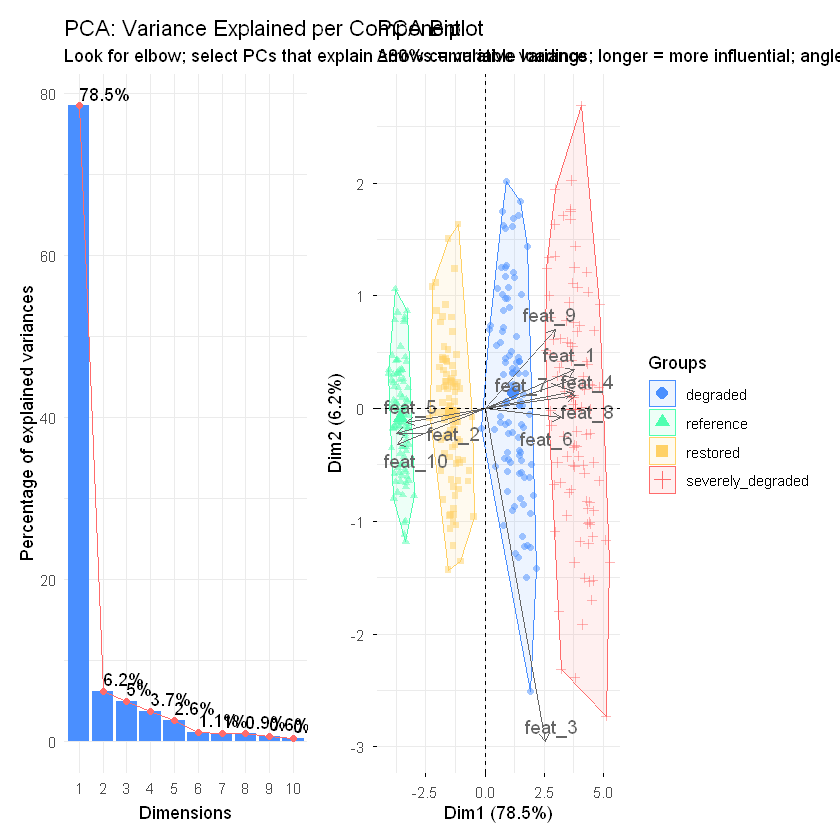

In [7]:
pca_fit <- prcomp(X_sc, center=FALSE, scale.=FALSE)  # already scaled

# ── Scree plot: variance explained ───────────────────────────────────────────
p_scree <- factoextra::fviz_eig(
  pca_fit, addlabels=TRUE, ncp=10,
  barfill="#4a8fff", barcolor=NA, linecolor="#ff6b6b"
) +
  labs(title="PCA: Variance Explained per Component",
       subtitle="Look for elbow; select PCs that explain ≥80% cumulative variance") +
  theme_minimal()

# ── Biplot: observations + variable loadings ──────────────────────────────────
p_biplot <- factoextra::fviz_pca_biplot(
  pca_fit,
  habillage   = groups,
  palette     = c("#4a8fff","#4fffb0","#ffd166","#ff6b6b"),
  addEllipses = TRUE, ellipse.type="convex",
  label       = "var",
  col.var     = "gray40",
  repel       = TRUE,
  alpha.ind   = 0.5,
  ggtheme     = theme_minimal()
) +
  labs(title="PCA Biplot",
       subtitle="Arrows = variable loadings; longer = more influential; angle = correlation")

(p_scree | p_biplot)

# ── Loadings table ────────────────────────────────────────────────────────────
loadings_df <- as_tibble(pca_fit$rotation[,1:3], rownames="feature") %>%
  mutate(across(where(is.numeric), ~round(.x, 3)))
cat("\nPC1-3 loadings:\n")
print(loadings_df)

---

## t-SNE

Using 4 PCs (93.3% variance explained)


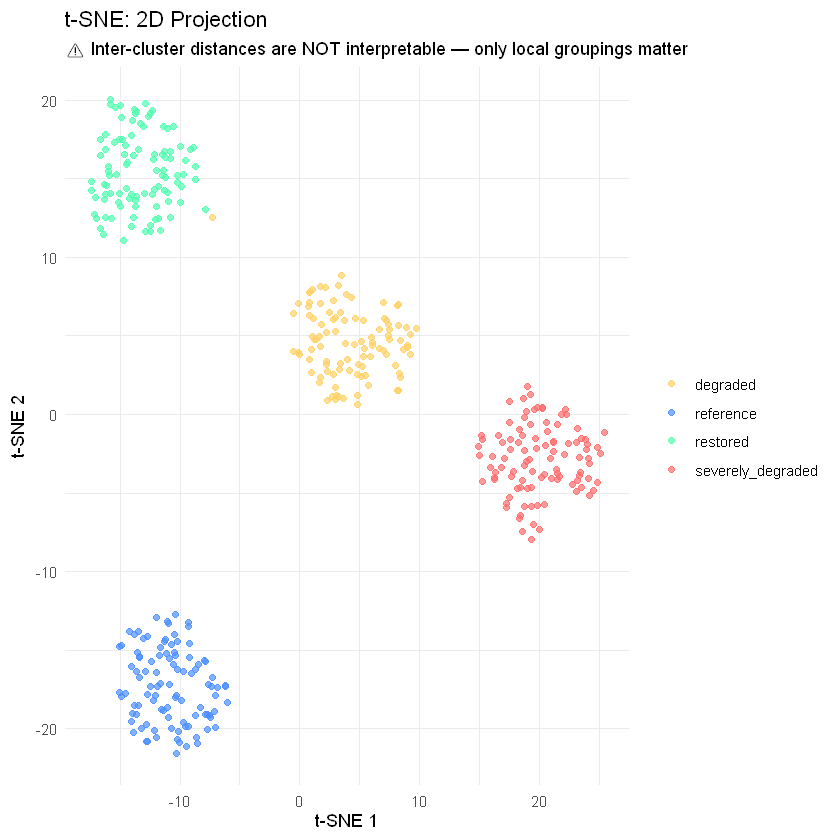

In [8]:
# Use PCA scores as input to t-SNE: reduces noise, speeds up computation
# Keep enough PCs to explain ~90% variance
cum_var <- cumsum(pca_fit$sdev^2 / sum(pca_fit$sdev^2))
n_pcs   <- which(cum_var >= 0.90)[1]
cat(sprintf("Using %d PCs (%.1f%% variance explained)\n",
            n_pcs, cum_var[n_pcs]*100))
pca_scores <- pca_fit$x[, 1:n_pcs]

# t-SNE key parameters:
# perplexity: effective neighbourhood size; typically 5-50; try multiple
# theta: speed/accuracy trade-off; 0 = exact Barnes-Hut t-SNE
tsne_fit <- Rtsne::Rtsne(
  pca_scores,
  dims        = 2,
  perplexity  = 30,
  max_iter    = 1000,
  theta       = 0.5,
  check_duplicates = FALSE,
  verbose     = FALSE
)

tsne_df <- tibble(
  tSNE1 = tsne_fit$Y[,1],
  tSNE2 = tsne_fit$Y[,2],
  group = groups
)

ggplot(tsne_df, aes(x=tSNE1, y=tSNE2, color=group)) +
  geom_point(alpha=0.7, size=1.5) +
  scale_color_manual(values=c(reference="#4a8fff",restored="#4fffb0",
                               degraded="#ffd166",severely_degraded="#ff6b6b")) +
  labs(title="t-SNE: 2D Projection",
       subtitle="⚠ Inter-cluster distances are NOT interpretable — only local groupings matter",
       x="t-SNE 1", y="t-SNE 2", color=NULL) +
  theme_minimal()

---

## UMAP

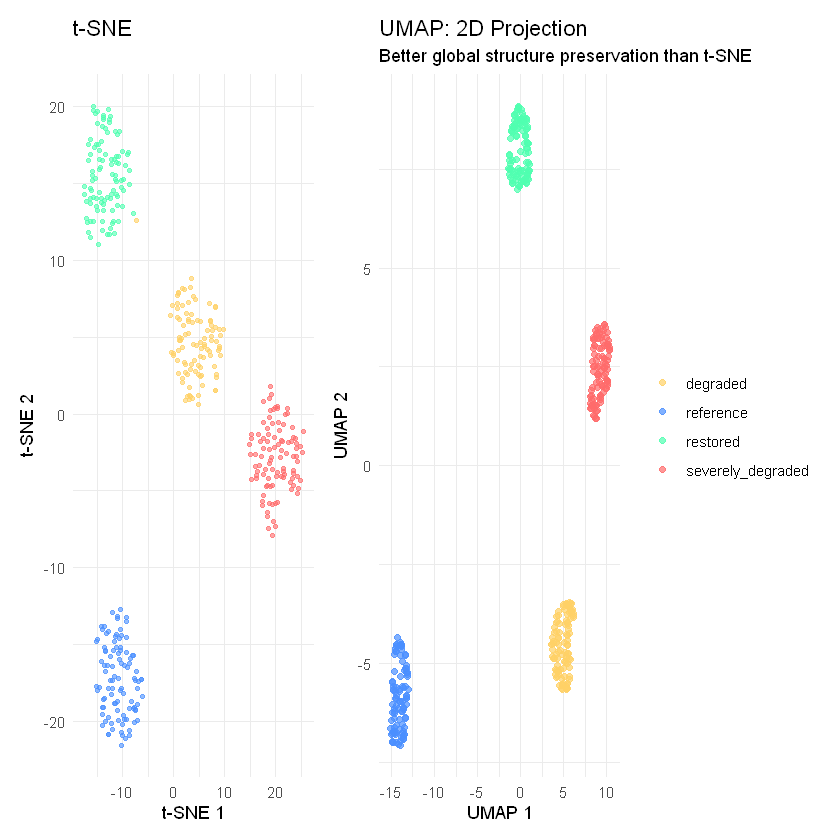

In [9]:
# UMAP key parameters:
# n_neighbors: local neighbourhood size (15-50); smaller = more local structure
# min_dist: minimum distance in 2D embedding (0.01-0.5); smaller = tighter clusters

umap_fit <- uwot::umap(
  pca_scores,
  n_neighbors  = 15,
  min_dist     = 0.1,
  n_components = 2,
  metric       = "euclidean",
  seed         = 42
)

umap_df <- tibble(
  UMAP1 = umap_fit[,1],
  UMAP2 = umap_fit[,2],
  group = groups
)

p_umap <- ggplot(umap_df, aes(x=UMAP1, y=UMAP2, color=group)) +
  geom_point(alpha=0.7, size=1.5) +
  scale_color_manual(values=c(reference="#4a8fff",restored="#4fffb0",
                               degraded="#ffd166",severely_degraded="#ff6b6b")) +
  labs(title="UMAP: 2D Projection",
       subtitle="Better global structure preservation than t-SNE",
       x="UMAP 1", y="UMAP 2", color=NULL) +
  theme_minimal()

# Side-by-side comparison
p_tsne_small <- ggplot(tsne_df, aes(x=tSNE1, y=tSNE2, color=group)) +
  geom_point(alpha=0.6, size=1.2) +
  scale_color_manual(values=c(reference="#4a8fff",restored="#4fffb0",
                               degraded="#ffd166",severely_degraded="#ff6b6b"),
                     guide="none") +
  labs(title="t-SNE", x="t-SNE 1", y="t-SNE 2") + theme_minimal()

(p_tsne_small | p_umap)

---

## Common Pitfalls

**1. Interpreting inter-cluster distances in t-SNE/UMAP plots**  
The distance between two clusters in a t-SNE or UMAP plot has no reliable meaning. Clusters that appear far apart may be close in the original space; clusters that appear close may be far apart. Only the *presence of tight local groupings* can be interpreted from these plots — not their relative positions or sizes.

**2. Using t-SNE/UMAP results to count clusters**  
The number of visual blobs in a t-SNE/UMAP plot depends heavily on perplexity/n_neighbors. The same data can show 3 or 8 apparent clusters by changing these parameters. Always base k selection on validation metrics (silhouette, CH, DB) applied in the original feature space, not on the 2D projection.

**3. Running t-SNE/UMAP on raw high-dimensional data without PCA first**  
For data with many features (p > 30), applying t-SNE/UMAP directly is slow, noisy, and prone to capturing artefacts from irrelevant dimensions. First reduce to the principal components that explain ~90% of variance, then apply t-SNE/UMAP on the PCA scores.

**4. Using PCA loadings to interpret UMAP/t-SNE axes**  
PCA axes are interpretable via loadings. UMAP and t-SNE axes are not — they are arbitrary rotations of a non-linear embedding. Do not label UMAP axes with feature names or treat axis direction as meaningful.

**5. Not checking PCA results for dominant outlier-driven variance**  
A single outlier can dominate PC1 in PCA, making the first component entirely about distance from the outlier rather than meaningful biological variation. Always inspect score plots coloured by individual features and check for extreme outliers before interpreting loadings.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*